In [1]:
import os, gzip, math, time, heapq, random, statistics, urllib.request
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tracemalloc
print("Setup OK")


Setup OK


In [2]:
DIMACS_URL  = "http://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.NY.gr.gz"
DIMACS_FILE = "USA-road-d.NY.gr.gz"

def download_dimacs():
    if os.path.exists(DIMACS_FILE):
        print(f"Already have {DIMACS_FILE} ({os.path.getsize(DIMACS_FILE)/1e6:.1f} MB)")
        return
        
    print(f"Downloading {DIMACS_URL} ...")
    req = urllib.request.Request(DIMACS_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as resp, open(DIMACS_FILE, 'wb') as f:
        f.write(resp.read())
    print(f"Downloaded ({os.path.getsize(DIMACS_FILE)/1e6:.1f} MB)")

def load_dimacs(path=DIMACS_FILE):
    adj, edges, n = None, [], 0
    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('p '):
                n = int(line.split()[2])
                adj = [[] for _ in range(n)]
            elif line.startswith('a '):
                _, u, v, w = line.split()
                u, v, w = int(u)-1, int(v)-1, int(w)
                adj[u].append((v, w))
                edges.append((u, v, w))
    print(f"Loaded: {n:,} nodes, {len(edges):,} edges (DIMACS NY road network)")
    return n, adj, edges

download_dimacs()
N_FULL, ADJ_FULL, EDGES_FULL = load_dimacs()

Already have USA-road-d.NY.gr.gz (3.7 MB)
Loaded: 264,346 nodes, 733,846 edges (DIMACS NY road network)


In [3]:
def bfs_subgraph(adj, n, target_size, start=0):
    
    if target_size >= n:
        edges = [(u, v, w) for u in range(n) for v, w in adj[u]]
        return n, adj, edges
    
    visited = {start}
    queue = deque([start])
    order = [start]
    while queue and len(order) < target_size:
        u = queue.popleft()
        for v, _ in adj[u]:
            if v not in visited:
                visited.add(v)
                order.append(v)
                queue.append(v)
                if len(order) >= target_size:
                    break
    
    id_map = {old: new for new, old in enumerate(order)}
    sub_adj = [[] for _ in range(len(order))]
    sub_edges = []
    for old_u in order:
        new_u = id_map[old_u]
        for old_v, w in adj[old_u]:
            if old_v in id_map:
                sub_adj[new_u].append((id_map[old_v], w))
                sub_edges.append((new_u, id_map[old_v], w))
    return len(order), sub_adj, sub_edges

print("BFS subgraph ready")

BFS subgraph ready


In [4]:
def dijkstra(graph, src, n):
    dist = [float('inf')] * n
    dist[src] = 0
    pq = [(0, src)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in graph[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist

In [5]:
def bellman_ford(edges, src, n):
    dist = [float('inf')] * n
    dist[src] = 0
    for _ in range(n - 1):
        updated = False
        for u, v, w in edges:
            if dist[u] != float('inf') and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                updated = True
        if not updated:
            break
    has_neg_cycle = any(dist[u] != float('inf') and dist[u] + w < dist[v]
                        for u, v, w in edges)
    return dist, has_neg_cycle

In [6]:
def bmssp(graph, src, n):
    dist = [float('inf')] * n
    dist[src] = 0
    pq = [(0, src)]
    t = max(2, int(math.log2(max(n, 2)) ** (2/3)))  

    while pq:
        
        batch = []
        while pq and len(batch) < t:
            d, u = heapq.heappop(pq)
            if d == dist[u]:
                batch.append(u)
       
        for u in batch:
            for v, w in graph[u]:
                nd = dist[u] + w
                if nd < dist[v]:
                    dist[v] = nd
                    heapq.heappush(pq, (nd, v))
    return dist

In [15]:
def cross_validate(size=500, seeds=[42, 123, 7, 999]):
    print("=== Cross-Validation: 3 algoritma da aynı mesafeleri vermeli sağlamasını yapıyorum yani===")
    for seed in seeds:
        sub_n, sub_adj, sub_edges = bfs_subgraph(ADJ_FULL, N_FULL, size, start=seed*100)
        d1 = dijkstra(sub_adj, 0, sub_n)
        d2, nc = bellman_ford(sub_edges, 0, sub_n)
        d3 = bmssp(sub_adj, 0, sub_n)
        ok = (d1 == d2 == d3) and not nc
        print(f"  seed={seed:>4} | n={sub_n} | Dijkstra==BF==BMSSP: {'✓' if ok else '✗ FAIL'}")
        assert ok, "Algoritmalar farklı sonuç verdi!"
    print("Tüm testler başarılı çünkü kmler eşit çıktı — implementasyonlar doğru\n")

cross_validate()

=== Cross-Validation: 3 algoritma da aynı mesafeleri vermeli sağlamasını yapıyorum yani===
  seed=  42 | n=500 | Dijkstra==BF==BMSSP: ✓
  seed= 123 | n=500 | Dijkstra==BF==BMSSP: ✓
  seed=   7 | n=500 | Dijkstra==BF==BMSSP: ✓
  seed= 999 | n=500 | Dijkstra==BF==BMSSP: ✓
Tüm testler başarılı çünkü kmler eşit çıktı — implementasyonlar doğru



In [16]:
def measure(func, args, trials=3):
    times, mems = [], []
    for _ in range(trials):
        tracemalloc.start()
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        times.append((t1 - t0) * 1000)
        mems.append(peak / 1024)
    return statistics.mean(times), statistics.stdev(times) if trials > 1 else 0, statistics.mean(mems)

print("Benchmark fonksiyonu hazır")

Benchmark fonksiyonu hazır


In [23]:
SIZES = [1000, 5000, 10000, 25000, 50000]
TRIALS = 3

results = []
for size in SIZES:
    sub_n, sub_adj, sub_edges = bfs_subgraph(ADJ_FULL, N_FULL, size)
    print(f"\n→ n={sub_n:,}, m={len(sub_edges):,}")

    dj_t, dj_s, dj_m = measure(dijkstra, (sub_adj, 0, sub_n), trials=TRIALS)
    bm_t, bm_s, bm_m = measure(bmssp,    (sub_adj, 0, sub_n), trials=TRIALS)
    bf_t, bf_s, bf_m = measure(lambda e,s,n: bellman_ford(e,s,n)[0],
                               (sub_edges, 0, sub_n), trials=TRIALS)

    print(f"  Dijkstra={dj_t:8.2f}±{dj_s:.2f}ms | BF={bf_t:9.2f}±{bf_s:.2f}ms | BMSSP={bm_t:8.2f}±{bm_s:.2f}ms")

    results.append({
        'n': sub_n, 'm': len(sub_edges),
        'Dijkstra (ms)': round(dj_t, 3), 'Dij_std': round(dj_s, 3),
        'Bellman-Ford (ms)': round(bf_t, 3), 'BF_std': round(bf_s, 3),
        'BMSSP (ms)': round(bm_t, 3), 'BMSSP_std': round(bm_s, 3),
        'Dijkstra (KB)': round(dj_m, 1),
        'Bellman-Ford (KB)': round(bf_m, 1),
        'BMSSP (KB)': round(bm_m, 1),
    })

df = pd.DataFrame(results)
df.to_csv('dimacs_benchmark.csv', index=False)
print("\n=== Sonuçlar ==")
print(df.to_string(index=False))


→ n=1,000, m=2,438
  Dijkstra=    2.95±0.84ms | BF=    16.92±1.97ms | BMSSP=    3.96±0.11ms

→ n=5,000, m=12,126
  Dijkstra=    9.19±0.17ms | BF=   152.99±1.66ms | BMSSP=   12.88±0.13ms

→ n=10,000, m=23,954
  Dijkstra=   18.62±0.11ms | BF=   785.06±11.32ms | BMSSP=   26.56±0.76ms

→ n=25,000, m=62,164
  Dijkstra=   53.87±3.76ms | BF=  3102.63±34.08ms | BMSSP=   74.56±1.85ms

→ n=50,000, m=130,522
  Dijkstra=  108.11±0.43ms | BF= 11717.98±184.47ms | BMSSP=  150.36±4.59ms

=== Sonuçlar ===
    n      m  Dijkstra (ms)  Dij_std  Bellman-Ford (ms)  BF_std  BMSSP (ms)  BMSSP_std  Dijkstra (KB)  Bellman-Ford (KB)  BMSSP (KB)
 1000   2438          2.946    0.845             16.919   1.973       3.960      0.111           39.2               39.7        39.4
 5000  12126          9.191    0.172            152.987   1.663      12.876      0.130          195.5              196.7       195.5
10000  23954         18.624    0.113            785.061  11.322      26.561      0.756          390.8     

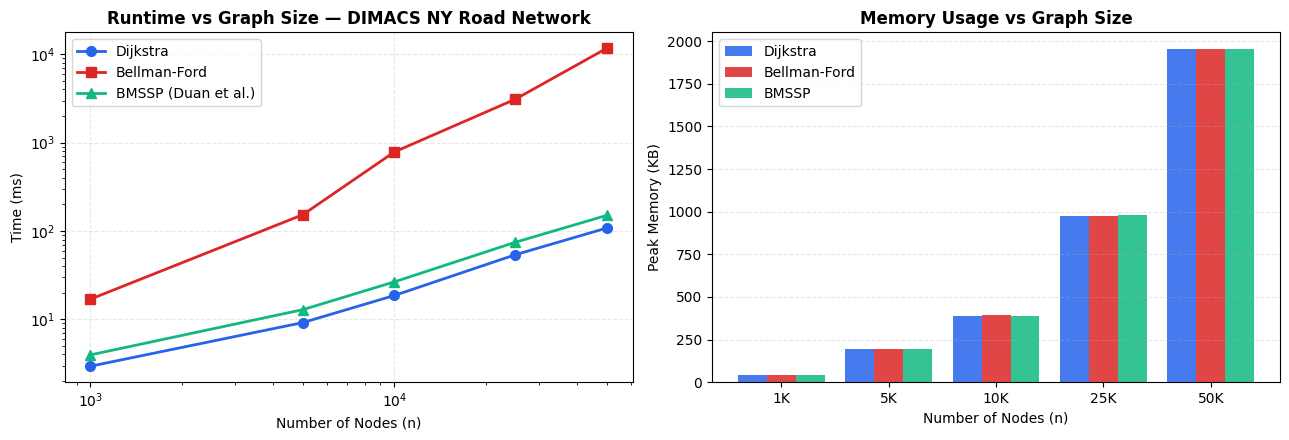

'dimacs_charts.png' kaydedildi.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ns = df['n'].tolist()

# RUNTIME
axes[0].plot(ns, df['Dijkstra (ms)'],     'o-', color='#2563EB', lw=2, ms=7, label='Dijkstra')
axes[0].plot(ns, df['Bellman-Ford (ms)'], 's-', color='#DC2626', lw=2, ms=7, label='Bellman-Ford')
axes[0].plot(ns, df['BMSSP (ms)'],        '^-', color='#10B981', lw=2, ms=7, label='BMSSP (Duan et al.)')
axes[0].set_title('Runtime vs Graph Size — DIMACS NY Road Network', fontweight='bold')
axes[0].set_xlabel('Number of Nodes (n)')
axes[0].set_ylabel('Time (ms)')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# MEMORY
x = np.arange(len(ns)); width = 0.27
axes[1].bar(x - width, df['Dijkstra (KB)'],     width, color='#2563EB', alpha=0.85, label='Dijkstra')
axes[1].bar(x,         df['Bellman-Ford (KB)'], width, color='#DC2626', alpha=0.85, label='Bellman-Ford')
axes[1].bar(x + width, df['BMSSP (KB)'],        width, color='#10B981', alpha=0.85, label='BMSSP')
axes[1].set_title('Memory Usage vs Graph Size', fontweight='bold')
axes[1].set_xlabel('Number of Nodes (n)')
axes[1].set_ylabel('Peak Memory (KB)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{n//1000}K" for n in ns])
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('dimacs_charts.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
print("=== Full DIMACS-NY Stres Test (264,346 nodes, 733,846 arcs) ===")

t0 = time.perf_counter()
d_full = dijkstra(ADJ_FULL, 0, N_FULL)
t1 = time.perf_counter()
print(f"Dijkstra (full NY): {(t1-t0)*1000:.1f} ms")

t0 = time.perf_counter()
d_bmssp = bmssp(ADJ_FULL, 0, N_FULL)
t1 = time.perf_counter()
print(f"BMSSP    (full NY): {(t1-t0)*1000:.1f} ms")

assert d_full == d_bmssp, "Full graph cross-validation failed!"
print(f"Full-graph cross-validation passed.")
print(f"Reachable nodes: {sum(1 for d in d_full if d < float('inf')):,} / {N_FULL:,}")
print(f"Max distance:    {max(d for d in d_full if d < float('inf')):,}")

=== Full DIMACS-NY Stress Test (264,346 nodes, 733,846 arcs) ===
Dijkstra (full NY): 243.0 ms
BMSSP    (full NY): 265.4 ms
Full-graph cross-validation passed.
Reachable nodes: 264,346 / 264,346
Max distance:    1,440,081
